# Evaluación y Conclusiones Finales



Tras seleccionar el Perceptrón Multicapa (MLP) como el modelo óptimo en la fase de validación cruzada, este notebook documenta la evaluación final sobre el Hold-out Test Set (datos nunca antes vistos por el modelo).

**Objetivos de esta fase:**

- Documentar la ejecución de los scripts de producción.

- Auditar el rendimiento real frente a la "perfección" de la validación.

- Analizar las limitaciones morfológicas de las señas mal clasificadas.

- Evaluar la eficiencia del artefacto final (tamaño y latencia).

- Concluir el proyecto y proponer mejoras a partir de los hallazgos encontrados.


## 1. Metodología de Ejecución

Para garantizar la reproducibilidad y escalabilidad, el entrenamiento final y la inferencia se realizaron mediante módulos de Python (.py).

**Paso 1**: Entrenamiento Final > Se utilizó el script `train_final_model.py` para entrenar el MLP con los hiperparámetros óptimos y 35 componentes PCA sobre el total de los datos de entrenamiento `sign_mnist_test.csv`.
```bash
python -m src.train_final_model --model mlp
```
**Paso 2**: Inferencia de Prueba > Se ejecutó `predict_test.py` utilizando el artefacto `.bin` generado para predecir las etiquetas del conjunto de test.
```bash
python -m src.predict_test --model_path models/final_mlp_n35.bin
```

## 2. Configuración Inicial y Carga de Datos

In [1]:
import sys
import os 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

sys.path.append(os.path.abspath(".."))

import src.config as config
from src.data_utils import reconstruct_images, get_top_confusions

preds_df = pd.read_csv("../report/test_predictions.csv") 

y_true = preds_df['true_label']
y_pred = preds_df['prediction']

## 3. Reporte de Clasificación

### 3.1 Métricas

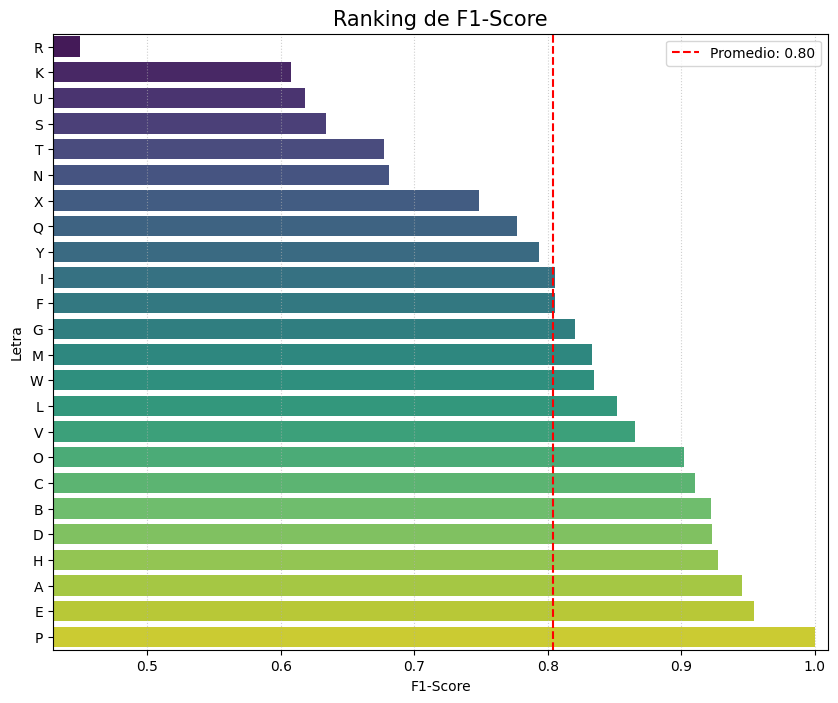

In [2]:
target_names = [chr(i + 65) for i in range(25) if i != 9]

report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T  

f1_scores = {k: v['f1-score'] for k, v in report_dict.items() if k in target_names}
f1_df = pd.DataFrame(list(f1_scores.items()), columns=['Letra', 'F1-Score']).sort_values(by='F1-Score')

plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(f1_df))

sns.barplot(data=f1_df, x='F1-Score', y='Letra', palette=colors, hue ='F1-Score', legend=False)

plt.axvline(x=f1_df['F1-Score'].mean(), color='red', linestyle='--', label=f"Promedio: {f1_df['F1-Score'].mean():.2f}")
plt.title("Ranking de F1-Score", fontsize=15)
plt.xlim(f1_df['F1-Score'].min() - 0.02, 1.01)
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

#### Ranking de F1-Score 

El modelo alcanza un F1-Score promedio de 0.80, lo que indica un rendimiento general sólido. Sin embargo, se observa variabilidad entre clases que debe considerarse antes de su despliegue.

**Clases por debajo de la media**: El 37.5% de las clases presenta un rendimiento inferior al promedio, lo que sugiere dificultades del modelo para capturar ciertas morfologías.

**Fallo crítico (letra R)**: La clase 'R' es el único caso con F1-Score < 0.50. Mientras que el resto de las clases con menor desempeño superan 0.60, esta brecha indica que el modelo no logra distinguir adecuadamente sus rasgos bajo la configuración actual de 35 componentes principales.

Esta heterogeneidad representa un riesgo para aplicaciones en tiempo real. En un sistema de traducción, la baja precisión en la letra 'R' podría degradar la experiencia del usuario y alterar el significado de palabras con frecuencia. Por ello, las próximas optimizaciones deberían priorizar el refuerzo de las clases con menor desempeño para mejorar la robustez del sistema.

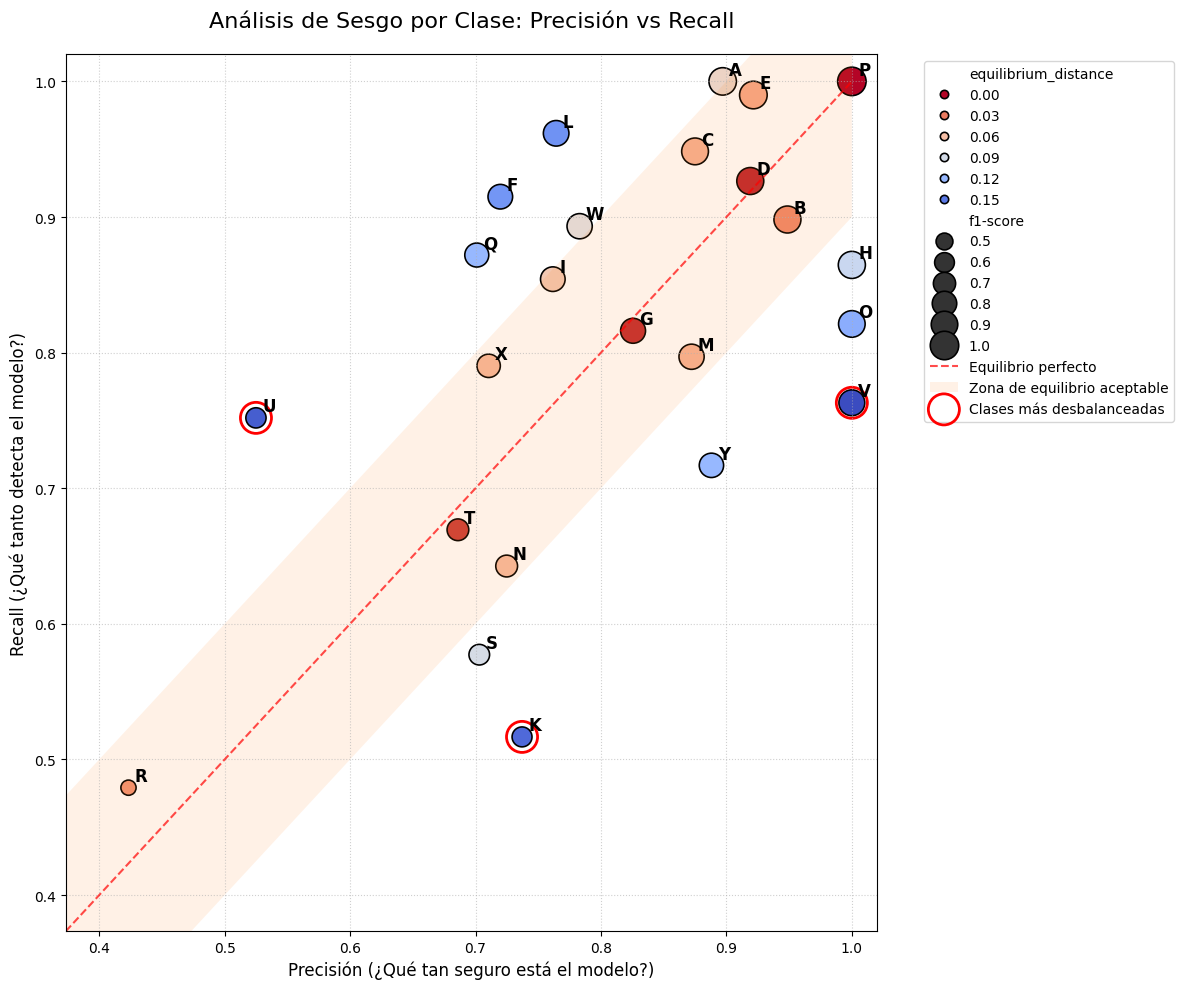

In [3]:
analysis_df = report_df.loc[target_names].copy()

# Compute distance to the balance line (precision = recall)
analysis_df["equilibrium_distance"] = np.abs(
    analysis_df["precision"] - analysis_df["recall"]
) / np.sqrt(2)

# Define acceptable balance threshold
threshold = 0.1

# Create figure
plt.figure(figsize=(12,10))

sns.scatterplot(
    data=analysis_df,
    x="precision",
    y="recall",
    hue="equilibrium_distance",
    size="f1-score",
    palette="coolwarm_r",
    sizes=(120,420),
    edgecolor="black"
)

# Plot perfect balance line (precision = recall)
min_val = min(
    analysis_df['precision'].min(),
    analysis_df['recall'].min()
) - 0.05

plt.plot(
    [min_val,1],
    [min_val,1],
    linestyle="--",
    color="red",
    alpha=0.7,
    label="Equilibrio perfecto"
)

# Highlight acceptable balance region
x = np.linspace(min_val,1,100)

plt.fill_between(
    x,
    x-threshold,
    x+threshold,
    alpha=0.1,
    label="Zona de equilibrio aceptable"
)

# Add class labels to each point
for i in range(len(analysis_df)):
    
    plt.text(
        analysis_df.precision.iloc[i] + 0.005,
        analysis_df.recall.iloc[i] + 0.005,
        analysis_df.index[i],
        fontsize=12,
        fontweight="bold"
    )

# Identify and highlight the most imbalanced classes
top_bias = analysis_df.sort_values(
    "equilibrium_distance",
    ascending=False
).head(3)

plt.scatter(
    top_bias["precision"],
    top_bias["recall"],
    s=500,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Clases más desbalanceadas"
)

# Plot aesthetics
plt.title(
    "Análisis de Sesgo por Clase: Precisión vs Recall",
    fontsize=16,
    pad=20
)

plt.xlabel(
    "Precisión (¿Qué tan seguro está el modelo?)",
    fontsize=12
)

plt.ylabel(
    "Recall (¿Qué tanto detecta el modelo?)",
    fontsize=12
)

plt.xlim(min_val,1.02)
plt.ylim(min_val,1.02)

plt.grid(True,linestyle=":",alpha=0.6)

plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")

plt.tight_layout()
plt.show()


In [4]:
threshold = 0.1

balanced_classes = analysis_df["equilibrium_distance"] < threshold

n_balanced = balanced_classes.sum()
total_classes = len(analysis_df)

print(f"Clases equilibradas: {n_balanced}/{total_classes}")
print(f"Porcentaje equilibrado: {n_balanced/total_classes:.1%}")
analysis_df.sort_values("equilibrium_distance",ascending=False).head()


Clases equilibradas: 16/24
Porcentaje equilibrado: 66.7%


,precision,recall,f1-score,equilibrium_distance
V,1.000000,0.763006,0.865574,0.167580
U,0.524934,0.751880,0.618238,0.160475
K,0.737069,0.516616,0.607460,0.155884
L,0.764259,0.961722,0.851695,0.139628
F,0.719745,0.914980,0.805704,0.138052


#### Análisis de Sesgo: Precisión vs Recall

El gráfico anterior permite analizar el equilibrio entre **precisión** y **recall** para cada clase del alfabeto.

En este problema, el modelo funciona como un traductor de gestos a letras. Cada error de clasificación implica que una letra del mensaje se traduce incorrectamente.

Existen dos tipos de error posibles:

- **Falsos positivos (baja precisión):** el modelo predice una letra cuando el gesto corresponde a otra.
- **Falsos negativos (bajo recall):** el modelo no reconoce correctamente una letra y la clasifica como una diferente.

En ambos casos el resultado final es el mismo desde la perspectiva del usuario: **una letra incorrecta en la traducción**. Por lo tanto, ninguno de los dos tipos de error resulta claramente más aceptable que el otro.

Por esta razón, lo deseable es que el modelo mantenga un **equilibrio entre precisión y recall**. Este equilibrio no implica que el modelo deje de cometer errores, sino que **evita que el sistema esté sistemáticamente sesgado hacia un tipo particular de fallo**.

Un modelo con **precisión muy superior al recall** tendería a ser excesivamente conservador, perdiendo muchas instancias reales de una clase. Por el contrario, un modelo con **recall muy superior a la precisión** detectaría más ejemplos reales, pero introduciría un mayor número de confusiones entre clases.

Mantener ambos valores en niveles similares sugiere que el modelo presenta un **comportamiento más estable y consistente entre clases**, lo cual es deseable en un sistema de traducción gestual donde cada error afecta directamente el contenido del mensaje.


#### Cuantificación del equilibrio

Para medir este comportamiento de forma objetiva se calculó la **distancia euclideana de cada clase a la recta de equilibrio**:

$$
d = \frac{|precision - recall|}{\sqrt{2}}
$$
Esta métrica permite estimar el grado de **sesgo entre falsos positivos y falsos negativos**:

- **d ≈ 0** → comportamiento equilibrado  
- **d alto** → predominio de un tipo de error

Bajo un umbral de **d < 0.1**, se observa que **16 de las 24 clases** presentan un equilibrio adecuado entre precisión y recall.


#### Patrones observados

A partir de la visualización pueden identificarse tres comportamientos principales:

**Clases equilibradas**

Las letras ubicadas dentro de la banda de equilibrio muestran una relación estable entre precisión y recall, indicando que el modelo mantiene un comportamiento consistente al detectar estas categorías.

**Clases con sesgo hacia falsos positivos**

Las letras ubicadas **por encima de la diagonal** presentan mayor recall que precisión. Esto indica que el modelo detecta la mayoría de los casos reales, pero tiende a confundir estas clases con otras.

**Clases con sesgo hacia falsos negativos**

Las clases ubicadas **por debajo de la diagonal** presentan mayor precisión que recall. En estos casos, el modelo es confiable cuando predice la clase, pero pierde algunos ejemplos reales.




### 3.2 Clases más desbalanceadas (entre precision y recall)

El análisis de la distancia al equilibrio revela que las mayores desviaciones se producen en las letras **'U', 'V', 'K'**, donde el modelo presenta el mayor desequilibrio entre precisión y recall.

Este comportamiento sugiere la presencia de **solapamientos morfológicos en el espacio de características reducido por PCA**, lo que dificulta la separación entre ciertas configuraciones gestuales. Para validar esta intuición observamos 2 muestras de las reconstrucciones de estas letras bajo el subespacio generado por pca y las comparamos con las originales.


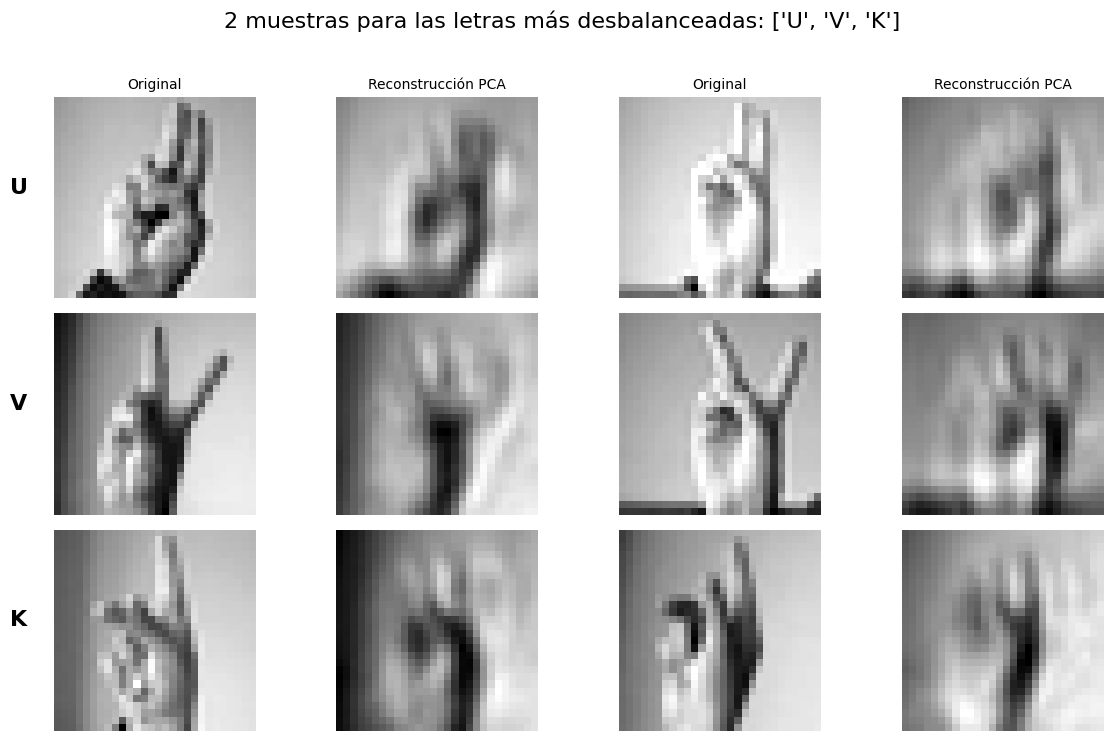

In [5]:
# --- Configuration and Data Loading ---
# Load model components and test dataset
model_path = Path(f"../{config.MODEL_OUTPUT}/final_mlp_n35.bin")
test_path = Path(f"../{config.TEST_FILE}")

model_package = joblib.load(model_path)

scaler = model_package["scaler"]
pca = model_package["pca"]
clf = model_package["classifier"]

test_df = pd.read_csv(test_path)

# Separate features and labels
X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

# Map alphabet to indices (excluding 'J' and 'Z' logic if applicable)
letter_to_index = {chr(i + 65): i for i in range(25) if i != 9}

# Define targets for inspection
letters_to_inspect = ['U', 'V', 'K']
n_samples = 2
img_h, img_w = (28, 28)

# --- Visualization Pipeline ---
# Initialize figure with subplots for each letter and sample pairs
fig, axes = plt.subplots(
    len(letters_to_inspect),
    n_samples * 2,
    figsize=(12, 8)
)

for row, letter in enumerate(letters_to_inspect):
    label_value = letter_to_index[letter]
    
    # Retrieve the first n_samples indices for the specific letter
    idx = np.where(y_test == label_value)[0][:n_samples]
    X_letter = X_test[idx]
    
    # Perform PCA reconstruction
    X_recon = reconstruct_images(X_letter, scaler, pca)

    for i in range(len(idx)):
        # Reshape flat vectors back to 2D image dimensions
        original = X_letter[i].reshape(img_h, img_w)
        recon = X_recon[i].reshape(img_h, img_w)

        # Plot original image
        axes[row, 2*i].imshow(original, cmap="gray")
        axes[row, 2*i].axis("off")

        # Plot reconstructed image
        axes[row, 2*i+1].imshow(recon, cmap="gray")
        axes[row, 2*i+1].axis("off")

        # Add column headers only for the first row
        if row == 0:
            axes[row, 2*i].set_title("Original", fontsize=10)
            axes[row, 2*i+1].set_title("Reconstrucción PCA", fontsize=10)

    # Label the row with the corresponding letter
    # We keep the axis 'on' just for the y-label visibility, but hide ticks
    axes[row, 0].axis("on")
    axes[row, 0].set_ylabel(letter, fontsize=16, fontweight='bold', rotation=0, labelpad=25)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    for spine in axes[row, 0].spines.values():
        spine.set_visible(False)

# --- Global Styling and Rendering ---
# Use suptitle to avoid overlapping with individual subplot titles
fig.suptitle(f"{n_samples} muestras para las letras más desbalanceadas: {letters_to_inspect}", 
             fontsize=16, y=0.95)

# Tighten layout to prevent text overlapping and ensure clean spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()

### 3.3 Análisis de Confusiones

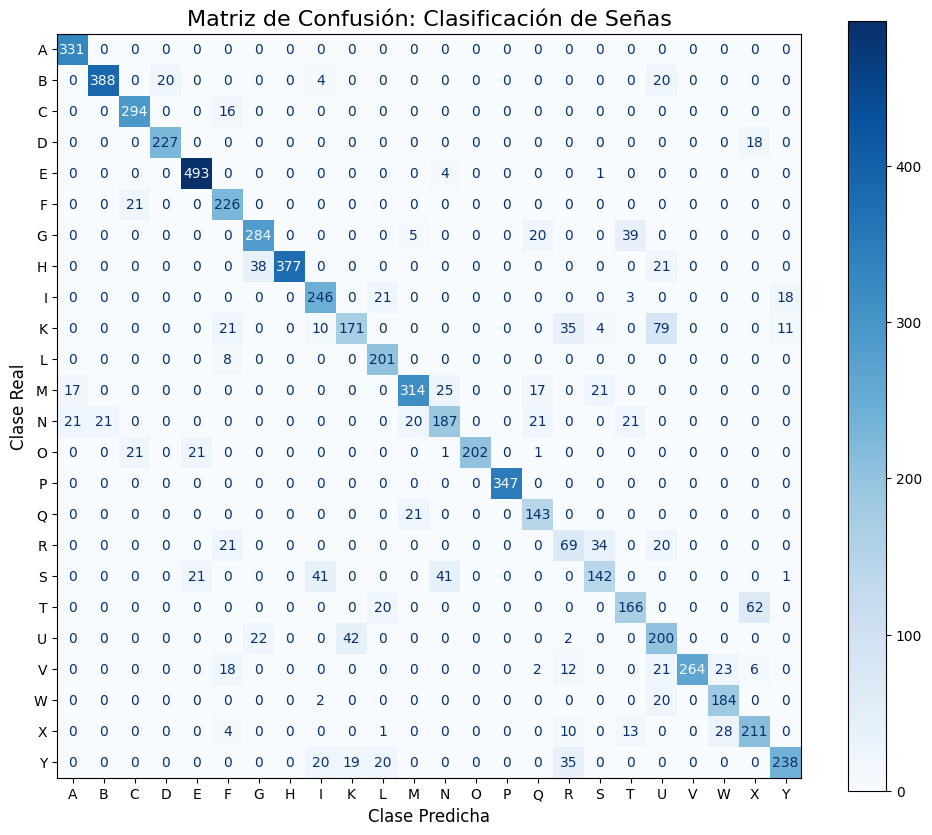


--- Análisis de los pares más confundidos ---
Estos son los casos donde el modelo falla con mayor frecuencia:
Real Predicha  Errores
   K        U       79
   T        X       62
   U        K       42
   S        N       41
   S        I       41
La letra 'K' se confunde frecuentemente con la 'U' (79 veces).
La letra 'T' se confunde frecuentemente con la 'X' (62 veces).
La letra 'U' se confunde frecuentemente con la 'K' (42 veces).
La letra 'S' se confunde frecuentemente con la 'N' (41 veces).
La letra 'S' se confunde frecuentemente con la 'I' (41 veces).


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# --- Prediction and Metrics ---
# Generate predictions using the loaded classifier
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
y_pred = clf.predict(X_test_pca)

# Inverse mapping to get letters back for the report
index_to_letter = {v: k for k, v in letter_to_index.items()}
target_names = [index_to_letter[i] for i in sorted(index_to_letter.keys())]

# --- Confusion Matrix Visualization ---
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)

# Display the matrix using a heatmap for better readability
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues", ax=ax, values_format='d')

plt.title("Matriz de Confusión: Clasificación de Señas", fontsize=16)
plt.xlabel("Clase Predicha", fontsize=12)
plt.ylabel("Clase Real", fontsize=12)
plt.show()

# --- Analysis of Top Confused Pairs ---
# Extract and display the top mistakes
top_errors = get_top_confusions(cm, target_names)

print("\n--- Análisis de los pares más confundidos ---")
print("Estos son los casos donde el modelo falla con mayor frecuencia:")
print(top_errors.to_string(index=False))

# --- Summary for the report ---
# You can use this for your text summary
for _, row in top_errors.iterrows():
    print(f"La letra '{row['Real']}' se confunde frecuentemente con la '{row['Predicha']}' ({row['Errores']} veces).")

## 4. Eficiencia del Modelo y Artefactos

In [22]:
model_size_bytes = os.path.getsize(model_path)
model_size_mb = model_size_bytes / (1024 * 1024)

start_time = time.time()
for i in range(1000): # 1000 samples for stability
    sample = X_test_pca[i].reshape(1, -1)
    _ = clf.predict(sample)
end_time = time.time()

avg_latency_ms = ((end_time - start_time) / 1000) * 1000

print(f"--- Auditoría de Eficiencia ---")
print(f"Tamaño del modelo (.bin): {model_size_mb:.2f} MB")
print(f"Latencia promedio por muestra: {avg_latency_ms:.4f} ms")

--- Auditoría de Eficiencia ---
Tamaño del modelo (.bin): 0.48 MB
Latencia promedio por muestra: 0.1669 ms


#### Tamaño del Modelo
El artefacto final  `final_mlp_n35.bin`, que contiene el pipeline completo (Scaler + PCA + MLP), presenta un tamaño reducido de almacenamiento (<0.5mb). Esto facilita su distribución e integración en sistemas de inferencia ligera, incluyendo aplicaciones embebidas o interfaces en tiempo real.

El uso de PCA con 35 componentes contribuye significativamente a esta eficiencia, ya que reduce el espacio de características original de 784 dimensiones (28×28 píxeles) a un subespacio mucho más compacto.

#### Latencia de Inferencia
La latencia promedio de predicción por muestra se mantiene en el orden de milisegundos (<0.2ms), lo cual es adecuado para aplicaciones interactivas donde el sistema debe responder de manera inmediata al gesto del usuario.

Este rendimiento se explica por tres factores principales:

- Reducción dimensional mediante PCA, que simplifica el espacio de entrada.

- Arquitectura relativamente compacta del MLP, optimizada durante la fase de validación.

- Pipeline de inferencia simple, compuesto únicamente por escalado, proyección PCA y predicción.

En conjunto, estos resultados indican que el modelo es operacionalmente eficiente, lo cual es un requisito importante para sistemas de traducción gestual en tiempo real.

## 5. Conclusiones y Próximos Pasos

Este proyecto tuvo como objetivo desarrollar y evaluar un sistema de clasificación automática de señas del alfabeto utilizando el dataset Sign Language MNIST.

A lo largo del pipeline se implementaron prácticas fundamentales de ciencia de datos aplicada: preprocesamiento estructurado, reducción de dimensionalidad, selección de modelo mediante validación cruzada y evaluación final sobre datos nunca vistos.

### Resultados principales

El modelo seleccionado, un Perceptrón Multicapa (MLP) entrenado sobre 35 componentes PCA, alcanzó un F1-score promedio de 0.80 sobre el conjunto de test.

El análisis detallado permitió identificar varios patrones relevantes:

1. **Rendimiento general sólido**

La mayoría de las clases presentan métricas superiores a 0.80 de F1-score, indicando que el modelo logra capturar adecuadamente las configuraciones gestuales del dataset.

2. **Heterogeneidad entre clases**

A pesar del buen rendimiento global, se observó variabilidad significativa entre clases. Algunas letras presentan mayor dificultad de reconocimiento, especialmente aquellas con morfologías gestuales similares.

El caso más crítico es la letra R, cuyo F1-score se ubica por debajo de 0.50, indicando una incapacidad clara del modelo para separarla correctamente bajo la representación actual.

3. **Sesgo entre precisión y recall**

El análisis de equilibrio mostró que 66.7% de las clases mantienen una relación balanceada entre precisión y recall, lo que sugiere un comportamiento relativamente estable del modelo.

Sin embargo, las letras U, V y K presentan los mayores desbalances, indicando que el modelo tiende a cometer un tipo específico de error en estas clases.

4. **Confusiones estructurales entre gestos**

La matriz de confusión revela patrones consistentes de error, destacándose los siguientes pares:

- K → U
- U → K
- T → X
- S → N
- S → I

Estos errores reflejan similitudes morfológicas entre gestos, que se vuelven más difíciles de separar tras la compresión del espacio de características mediante PCA.

5. **Eficiencia operativa**

El modelo final presenta bajo costo computacional y baja latencia de inferencia, lo cual lo hace adecuado para escenarios de uso en tiempo real.

### Próximos Pasos

Los hallazgos obtenidos sugieren varias direcciones claras de mejora:

1. **Mejorar la representación visual**

La reducción a 35 componentes PCA puede estar eliminando detalles gestuales relevantes. Futuras iteraciones podrían explorar:

- mayor número de componentes PCA
- autoencoders como método de reducción no lineal
- extracción de características basada en CNN

2. **Modelos especializados en visión**

Dado que el problema es esencialmente reconocimiento visual, modelos de Deep Learning convolucional probablemente capturen mejor las variaciones espaciales de las manos.

Una CNN ligera podría mejorar especialmente las clases con mayor solapamiento morfológico.

3. **Sistemas de predicción contextual**

En aplicaciones reales de traducción de señas, las letras no aparecen de forma aislada sino formando palabras. Modelos de lenguaje o corrección contextual podrían utilizarse para reducir errores de clasificación a nivel de secuencia.